In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(1)') 

array([2], dtype=int64)

In [ ]:
Main.eval("""
    @everywhere begin
        
        using Distributed
        using DelimitedFiles
        using HCubature
        using Interpolations
          
        Grid1 = readdlm("../Grid/Γoverμ_1.csv", ',')
        Grid2 = readdlm("../Grid/Γoverμ_2.csv", ',')
        Grid3 = readdlm("../Grid/Γoverμ_3.csv", ',')
        Grid4 = readdlm("../Grid/Γoverμ_4.csv", ',')

        lnGrid1 = readdlm("../Grid/lnΓoverμ_1.csv", ',')
        lnGrid2 = readdlm("../Grid/lnΓoverμ_2.csv", ',')
        lnGrid3 = readdlm("../Grid/lnΓoverμ_3.csv", ',')
        lnGrid4 = readdlm("../Grid/lnΓoverμ_4.csv", ',')
            
        α1Grid = readdlm("../Grid/α1overμ.csv", ',')
        α2Grid = readdlm("../Grid/α2overμ.csv", ',')
        α3Grid = readdlm("../Grid/α3overμ.csv", ',')
        α4Grid = readdlm("../Grid/α4overμ.csv", ',')  
            
    end      
""")
Main.include("..\\Grid\\interpolation.jl")

Main.include("..\\core\\constants.jl")
Main.include("..\\core\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\sigma.jl")
Main.include("..\\error.jl")
Main.include("..\\fixed order\\perturbation.jl")
Main.include("..\\fixed order\\SCET.jl")
Main.include("..\\fixed order\\non-singular.jl")
Main.include("..\\fit.jl")
Main.include("..\\NP.jl")
Main.include("..\\renormalon.jl")

<PyCall.jlwrap test_func>

In [4]:
χ_lower = 145
χ_upper = 175

In [5]:
optimal_params = [0.1173, 0.127, 0.443, 0.087]
#[0.11725829, 0.12684399, 0.44293446, 0.08641648]
NLL="N3LL"
χ_low = 115
χ_up = 175
if_renormalon = False

In [6]:
#-------------------------------------------------------------------
dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

In [7]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [8]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    #----------
    XLL = NLL
    XLO = 2 # 1:LO 2:NLO
    #----------

    N = 5
    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=abs(xlist_mid[1]-xlist_mid[0]) # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/4

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters, Ω1=Ω1)
                DELTA =  DELTA_func(ylist,PRED)
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, Ω1=Ω1)              
                DELTA =  DELTA_func(ylist,PRED)               
        else:
            parameters = params_noαs
            if len(parameters) > 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters)                
                DELTA =  DELTA_func(ylist,PRED)             
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO)              
                DELTA =  DELTA_func(ylist,PRED)              

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/length

Test

In [9]:
objective([0.1173, 0.127, 0.443, 0.087], df_truncated, Q_list, dataset_names, False)
#[0.1173, 0.127, 0.443, 0.0864]
#[0.11726608, 0.15176385, 0.4397221, 0.20731305]

1.0131590358325788

Import replicas 

In [10]:
result_set = {}
accuracies = ["bbstar_fit","bbstar_scan"]
#["log_fit_cut","log_fit","log_scan"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("../result/"+XLL+".csv")

In [11]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set[XLL] = a_list

    #print(a_list)

In [12]:
#print(N_params)
#print(N_replicas)
params_replicas={}
for XLL in accuracies:
    N_params = len(a_set[XLL])
    N_replicas = len(a_set[XLL][0])
    params_reps = []
    for i in range(N_replicas):
        params = []
        for j in range(N_params):
            value = a_set[XLL][j][i]
            params.append(value)
        params_reps.append(params)
    params_replicas[XLL]=params_reps

In [13]:
display(params_replicas)
display(αs_set)

{'bbstar_fit': [[0.13158, 0.46805, 0.09497],
  [0.36925, 0.44717, 0.04711],
  [0.11703, 0.40828, 0.08326],
  [0.01768, 0.48372, 0.10859],
  [0.12821, 0.44772, 0.08339],
  [0.40218, 0.43484, 0.03198],
  [0.12113, 0.48697, 0.08065],
  [0.13593, 0.48512, 0.07983],
  [0.61322, 0.38097, 0.0],
  [0.49441, 0.3831, 0.02239],
  [0.29919, 0.33796, 0.05045],
  [0.12688, 0.44302, 0.08703],
  [0.49521, 0.41987, 0.01924],
  [0.13938, 0.51031, 0.0803],
  [0.12417, 0.43366, 0.08457],
  [0.13298, 0.4674, 0.08872],
  [0.12302, 0.45965, 0.08361],
  [0.14362, 0.51991, 0.07722],
  [0.13716, 0.47998, 0.08001],
  [0.06365, 0.48373, 0.09489],
  [0.12193, 0.47963, 0.08573],
  [0.16923, 0.52009, 0.08186],
  [0.13147, 0.46808, 0.0812],
  [0.1362, 0.48207, 0.08778],
  [0.12412, 0.45384, 0.07636],
  [0.14158, 0.50986, 0.07828],
  [0.11367, 0.42157, 0.0918],
  [0.12631, 0.41847, 0.07148],
  [0.11649, 0.40703, 0.07915],
  [0.0, 0.49149, 0.10714],
  [0.60138, 0.43108, 0.0016],
  [0.14608, 0.47607, 0.09149],
  [0.0, 0

{'bbstar_fit': array([0.11552, 0.1163 , 0.11942, 0.11612, 0.11708, 0.11706, 0.11619,
        0.11568, 0.11827, 0.11828, 0.12088, 0.11729, 0.11682, 0.11574,
        0.11734, 0.1158 , 0.11719, 0.1144 , 0.11711, 0.11578, 0.11611,
        0.11486, 0.11634, 0.1151 , 0.11796, 0.11484, 0.11888, 0.11911,
        0.11879, 0.11561, 0.11622, 0.1156 , 0.1168 , 0.11628, 0.11765,
        0.11758, 0.1153 , 0.1154 , 0.1185 , 0.11439, 0.11807, 0.11567,
        0.11671, 0.11586, 0.11713, 0.11553, 0.11902, 0.11456, 0.11517,
        0.11794, 0.11815, 0.11906, 0.12139, 0.11478, 0.11808, 0.11899,
        0.11501, 0.11692, 0.11334, 0.11596, 0.11638, 0.1177 , 0.11836,
        0.11796, 0.11869, 0.11718, 0.11825, 0.11506, 0.11957, 0.11614,
        0.11694, 0.11701, 0.11705, 0.11441, 0.11772, 0.11904, 0.11936,
        0.11854, 0.11757, 0.11676, 0.11948, 0.11599, 0.11929, 0.11795,
        0.11456, 0.1164 , 0.11911, 0.11505, 0.1174 , 0.11689, 0.11757,
        0.11415, 0.11476, 0.11622, 0.11734, 0.11768, 0.1193 , 0

Calculate bands

In [16]:
xlist = np.pi/180*np.linspace(χ_low, 179.9, 200, endpoint=True)
length=len(xlist)

EEC_replicas = {}
for XLL in accuracies:
    i=0
    EEC_reps = []
    for params in tqdm(params_replicas[XLL]):
        #print(params) 
        EEC = {}
        for name in dataset_names:       
            v = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs_set[XLL][i], nf=5, XLL=NLL, parameters=params)
            non_singular=[]
            for x in xlist:
                non_singular.append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs_set[XLL][i], nf=5, order=2))   
            EEC[name] = np.array(v) + np.array(non_singular)                
        EEC_reps.append(EEC)
        i = i+1
    EEC_replicas[XLL] = EEC_reps

  0%|          | 0/200 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [17]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000019ccbad22f0>

In [14]:
EEC_upper = {}
EEC_lower = {}

for XLL in accuracies:
    EEC_up = {}
    EEC_low = {}
    for name in dataset_names: 
        upper_band = []
        lower_band = []
        for i in range(length):
            compare_list = []
            for j in range(N_replicas):
                value = EEC_replicas[XLL][j][name][i]
                compare_list.append(value)
            upper_EEC = np.percentile(compare_list,84)
            upper_band.append(upper_EEC)
            lower_EEC =np.percentile(compare_list,16)
            lower_band.append(lower_EEC)
        EEC_up[name]=upper_band
        EEC_low[name]=lower_band    
    EEC_upper[XLL] = EEC_up
    EEC_lower[XLL] = EEC_low 

import json
with open("../plot_data/bbstar_upper.json", "w") as file:
    json.dump(EEC_upper, file)
with open("../plot_data/bbstar_lower.json", "w") as file:
    json.dump(EEC_lower, file)

NameError: name 'length' is not defined

In [14]:
import json
EEC_upper = {}
EEC_lower = {}

with open("../plot_data/bbstar_upper.json", "r") as file:
    EEC_upper = json.load(file)
with open("../plot_data/bbstar_lower.json", "r") as file:
    EEC_lower = json.load(file)

for XLL in accuracies:
    display(np.array(EEC_upper[XLL]["SLD"])-np.array(EEC_lower[XLL]["SLD"]))

array([0.00196919, 0.00197735, 0.0019857 , 0.00199447, 0.00200339,
       0.00201247, 0.00202172, 0.00203116, 0.00204078, 0.00204997,
       0.0020585 , 0.00206743, 0.00207934, 0.00209147, 0.00210381,
       0.0021157 , 0.00212743, 0.00213937, 0.00215153, 0.00216391,
       0.00217651, 0.00218933, 0.00220236, 0.00221477, 0.00222713,
       0.00223975, 0.00225257, 0.0022655 , 0.0022785 , 0.00229178,
       0.00230533, 0.00232147, 0.00233878, 0.00235637, 0.00237424,
       0.0023924 , 0.00241085, 0.00242924, 0.0024468 , 0.00246464,
       0.00248279, 0.00250125, 0.00252001, 0.00253909, 0.00255849,
       0.00257821, 0.00259826, 0.00261865, 0.00263938, 0.00266045,
       0.00268187, 0.00270363, 0.00272533, 0.00274741, 0.00276987,
       0.00279339, 0.00281755, 0.00284215, 0.00286719, 0.00289268,
       0.00291863, 0.00294505, 0.00297194, 0.00299932, 0.00302719,
       0.00305556, 0.00308444, 0.00311385, 0.00314379, 0.00317427,
       0.0032053 , 0.0032369 , 0.00326906, 0.00330181, 0.00333

array([0.00112378, 0.00113913, 0.00115463, 0.0011703 , 0.00118613,
       0.00120213, 0.0012183 , 0.00123465, 0.00125105, 0.00126745,
       0.00128403, 0.00130079, 0.00131772, 0.0013345 , 0.00135168,
       0.00137106, 0.00139064, 0.00141044, 0.00143079, 0.00145072,
       0.00146998, 0.00148691, 0.00150392, 0.00152145, 0.00154023,
       0.00155786, 0.00157531, 0.00159297, 0.00161087, 0.00162838,
       0.00164599, 0.00166383, 0.0016819 , 0.00170086, 0.00172008,
       0.00173955, 0.00175926, 0.00177923, 0.00179945, 0.00181994,
       0.00184085, 0.00186243, 0.00188427, 0.00190638, 0.00192875,
       0.00195139, 0.00197432, 0.00199752, 0.00202398, 0.00205119,
       0.00207875, 0.00210666, 0.00213492, 0.00216355, 0.00219254,
       0.00222123, 0.00224813, 0.00227536, 0.00230264, 0.00232994,
       0.00236061, 0.00239236, 0.00242455, 0.0024572 , 0.00249031,
       0.00252312, 0.00255453, 0.00258636, 0.00261862, 0.00265131,
       0.00268444, 0.00272104, 0.00275934, 0.00279817, 0.00283

Central data

In [15]:
xlist = np.pi/180*np.linspace(χ_low, 179.9, 200, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}
central_data={}

for name in dataset_names:

    x_array=np.array(df[name]["CHI"])*np.pi/180
    
    parameters = params_noαs

    v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=x_array, μ_ini=91.1876, αs_ini=αs, nf=5, XLL=NLL, parameters=parameters)
    
    non_singular[name] = []
    for x in x_array:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

    central_data[name] = v[name] + non_singular[name]

In [16]:
display(central_data)

{'SLD': array([2.14969263e+09, 1.09111062e+05, 1.09783460e+03, 5.32291614e+01,
        5.70064027e+00, 1.06595472e+00, 3.40305682e-01, 1.77623257e-01,
        1.26928811e-01, 1.05226273e-01, 9.31307297e-02, 8.50997935e-02,
        7.92205800e-02, 7.47010167e-02, 7.11529707e-02, 6.83577449e-02,
        6.61789775e-02, 6.45261018e-02, 6.33371681e-02, 6.25699315e-02,
        6.21968738e-02, 6.22023177e-02, 6.25807774e-02, 6.33361442e-02,
        6.44815001e-02, 6.60394750e-02, 6.80431394e-02, 7.05374829e-02,
        7.35815796e-02, 7.72516304e-02, 8.16451452e-02, 8.68866657e-02,
        9.31356194e-02, 1.00597179e-01, 1.09537441e-01, 1.20304922e-01,
        1.33361496e-01, 1.49327711e-01, 1.69050517e-01, 1.93706792e-01,
        2.24965488e-01, 2.65248434e-01, 3.18161161e-01, 3.89220713e-01,
        4.87086481e-01, 6.25461524e-01, 8.24411913e-01, 1.09805744e+00,
        1.34338922e+00, 8.49848696e-01]),
 'TOPAZ_595': array([2.44842634e+09, 1.24273737e+05, 1.25037929e+03, 6.06142306e+01,
  

Calculate central

In [17]:
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}
central={}

for name in dataset_names:
    
    parameters = params_noαs

    v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL=NLL, parameters=parameters)
    
    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

    central[name] = v[name] + non_singular[name]

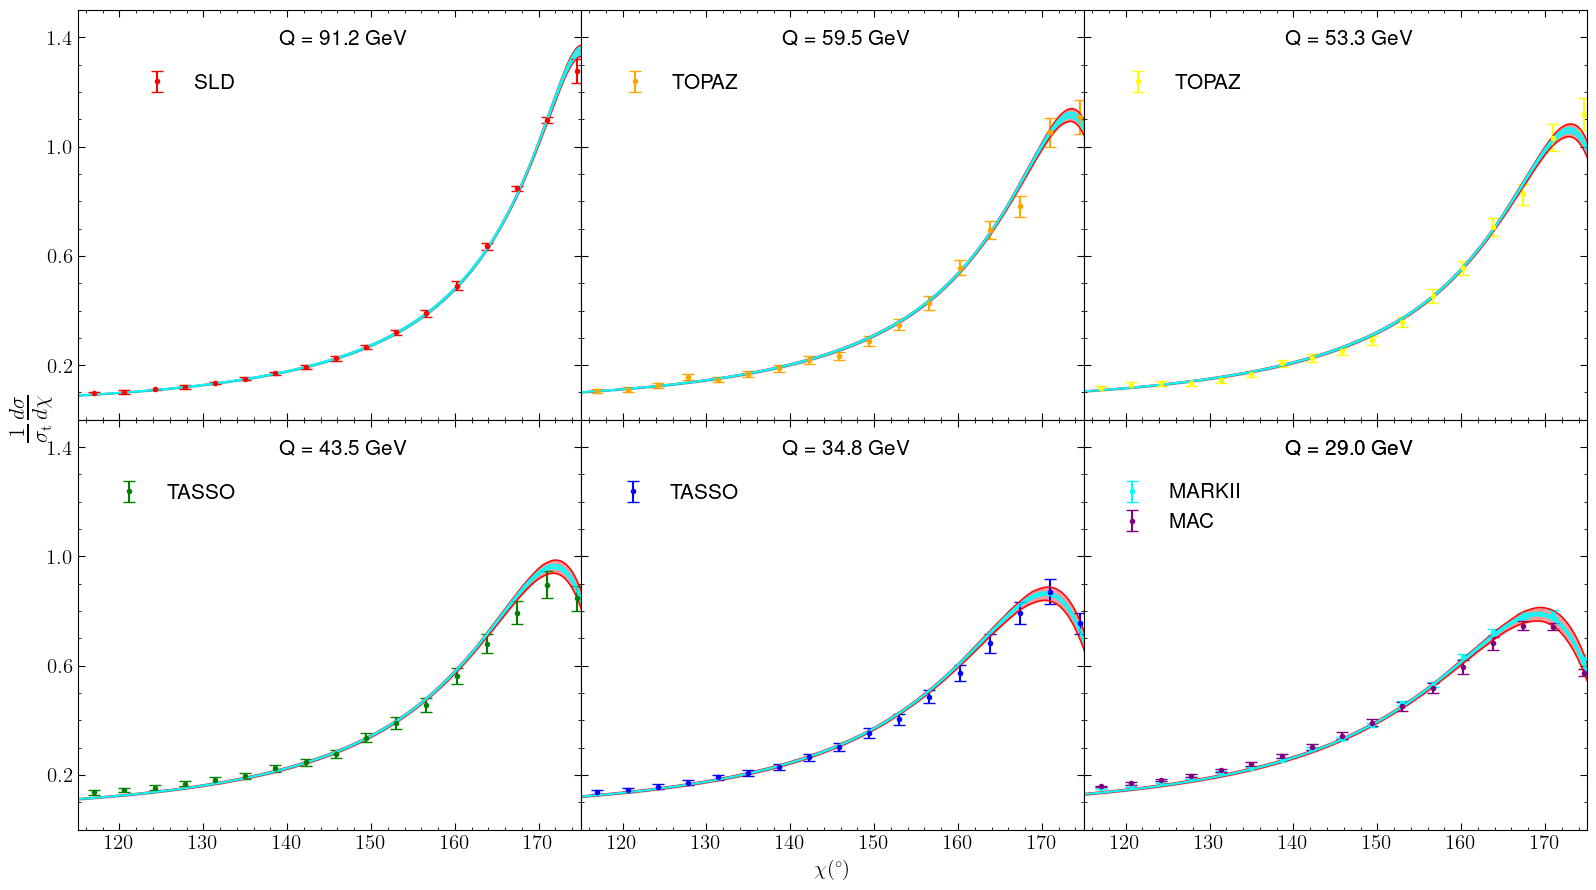

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15
props = dict(boxstyle='round', facecolor='white', alpha=0)

color = ["red","orange","yellow","green","blue","cyan","purple","black"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[j])
            j=j+1
    i=i+1

color_band=["red","cyan","blue"]
transparency=[0.4,0.7,1.0]
names_band=["SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII",]

j=0
for XLL in ["bbstar_scan","bbstar_fit"]:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                #ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[j])
                ax_list[i].fill_between(xlist*180/np.pi, EEC_upper[XLL][name], EEC_lower[XLL][name], alpha=transparency[j], color=color_band[j])
                ax_list[i].plot(xlist*180/np.pi, EEC_upper[XLL][name], color=color_band[j], linewidth=1)
                ax_list[i].plot(xlist*180/np.pi, EEC_lower[XLL][name], color=color_band[j], linewidth=1)
        i=i+1
    j=j+1

ax5.set_xlabel(r"\rm $\chi({^{\circ}})$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

#plt.ylim(0.0, 1.5)
#plt.yticks([0.2,0.6,1.0,1.4])
plt.ylim(0.0, 1.5)
plt.yticks([0.2,0.6,1.0,1.4])

#plt.xticks([150,160,170])
plt.xticks([120,130,140,150,160,170])
plt.xlim(χ_low,χ_up)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [19]:
accuracy = ["bbstar_scan","bbstar_fit"]

df_fitted={}
central_fitted={}
for name in dataset_names:
    df_fitted[name] = df[name][(df[name]["CHI"] >= χ_lower) & (df[name]["CHI"] <= χ_upper)]
    central_fitted[name] = central_data[name][40:49]

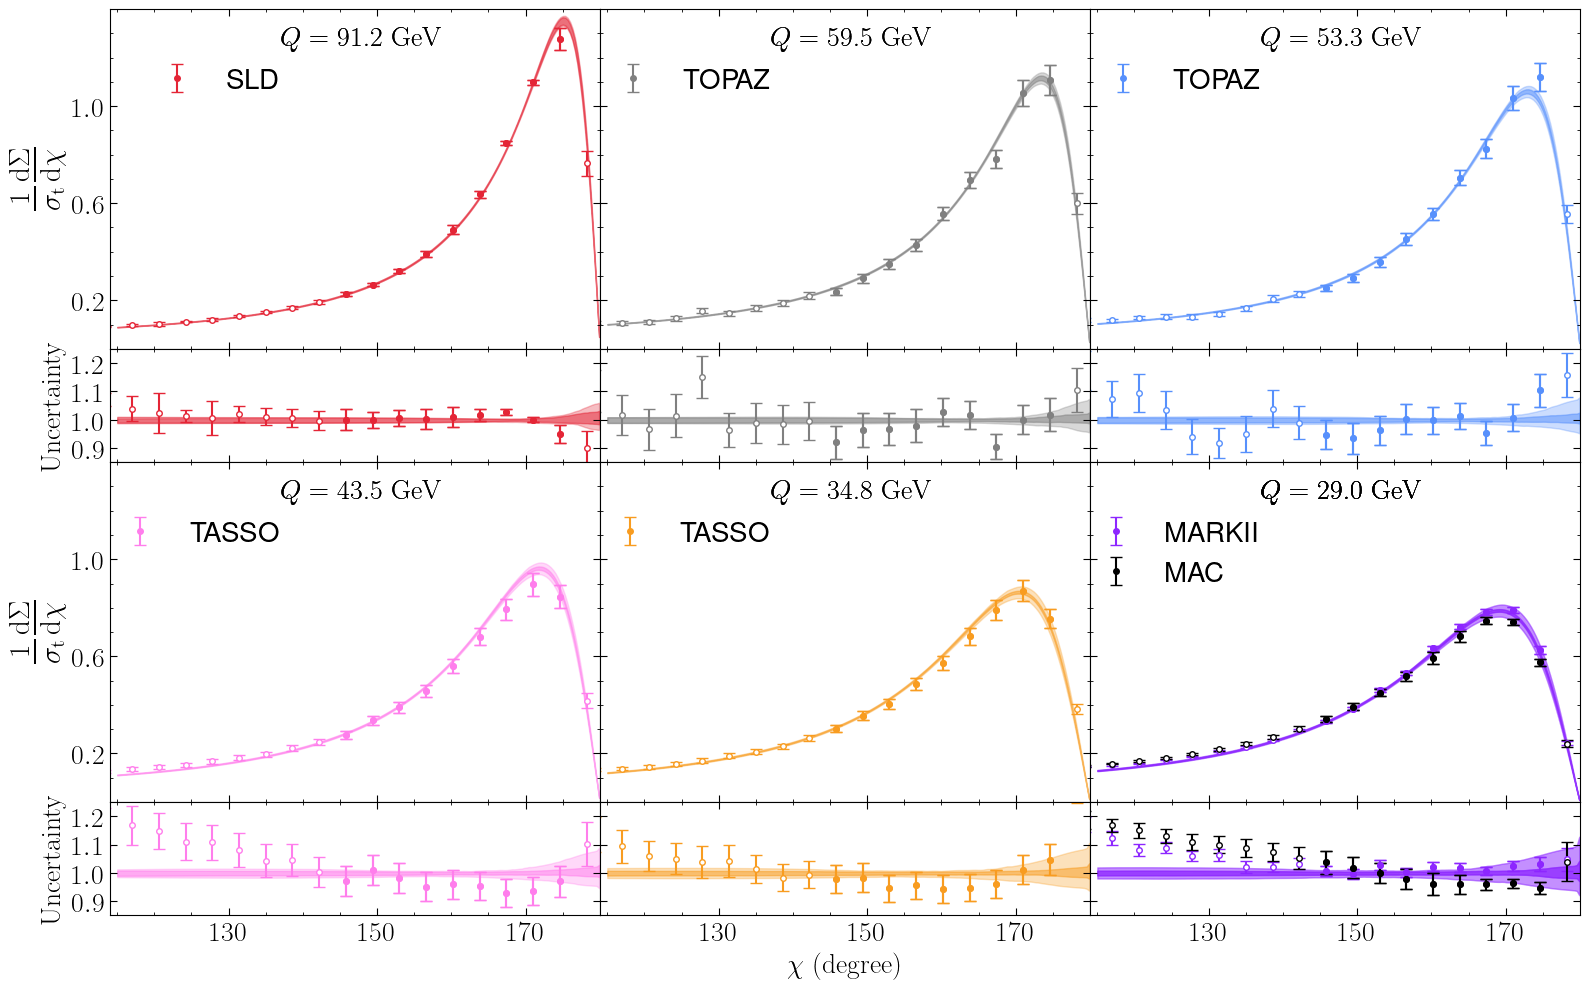

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [3, 1, 3, 1]})
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes.ravel()

#Settings-----------------------------------------------------------------
sizeOfFont= 20
sizeOfTick = 20
sizeOfCap = 4
sizeOfMark = 4

props = dict(boxstyle='round', facecolor='white', alpha=0)

#color = ["blue","green","blue","green","blue","green","blue"]
#color = ["red","orange","gray","teal","blue","purple","black"]

blue=(87/255,144/255,252/255)
orange=(248/255,156/255,32/255)
red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)
color = [red,"gray",blue,purple1,orange,purple2,"black"]

transparency=[0.3,0.5]

ax_list = [ax1,ax2,ax3,ax7,ax8,ax9]
ax_ratios = [ax4,ax5,ax6,ax10,ax11,ax12]

Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]
names_band=["SLD","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII","MAC"]
#--------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_list[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"], df_fitted[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap,markersize=sizeOfMark,label=str(name_set[name]))
            j=j+1
    i=i+1

j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_list[i].fill_between(xlist*180/np.pi, EEC_upper[XLL][name], EEC_lower[XLL][name], alpha=transparency[j], color=color[i])
                ax_list[i].text(0.35, 0.95, r"\rm $Q = \ $" + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #ax_list[i].plot(xlist*180/np.pi, EEC_upper[XLL][name], color=color[i], linewidth=1)
                #ax_list[i].plot(xlist*180/np.pi, EEC_lower[XLL][name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

for ax in ax_list:
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.4, 0.9))
    ax.set_xlim(χ_low,χ_up)
    ax.set_xticks([120,130,140,150,160,170])
    ax.set_ylim(0.0,1.4)
    ax.set_yticks([0.2,0.6,1.0])

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax8.set_yticklabels([])
ax9.set_yticklabels([])

ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
ax7.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_ratios[i].fill_between(xlist*180/np.pi, EEC_upper[XLL][name]/central[name], EEC_lower[XLL][name]/central[name], alpha=transparency[j], color=color[i])
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_upper[XLL][name]/central[name], color=color[i], linewidth=1)
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_lower[XLL][name]/central[name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

i=0
j=0
for Q in Q_set:
    for name in names_band:
        if Q_list[name]==Q:
            ax_ratios[i].errorbar(df[name]["CHI"], df[name]["EEC"]/central_data[name], df[name]["ERROR"]/central_data[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_ratios[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"]/central_fitted[name], df_fitted[name]["ERROR"]/central_fitted[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark)
            j=j+1
    i=i+1

for ax in ax_ratios:
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.set_xlim(114,180)
    ax.set_xticks([130,150,170])
    ax.set_ylim(0.85,1.25)
    ax.set_yticks([0.9,1.0,1.1,1.2])

ax5.set_yticklabels([])
ax6.set_yticklabels([])
ax11.set_yticklabels([])
ax12.set_yticklabels([])

ax4.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax10.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax11.set_xlabel(r"\rm $\chi \ (\rm{degree})$",fontsize=sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('fit_bbstar.pdf')